In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re
import json

data_dir = Path("/home/bjoern/Projects/Masterarbeit/simdata/server/benchmark")

filename_pattern = re.compile(
    r"base(\d+)agent(\d+)_(\d+)-(\d+)#(\d+)"
)

rows = []

for file in data_dir.iterdir():

    if file.suffix != ".json":
        continue

    match = filename_pattern.match(file.stem)

    if not match:
        print(f"Skipping {file.name}")
        continue

    experiment, agent, start, goal, run = map(int, match.groups())

    with open(file) as f:
        data = json.load(f)

    info = data["info"]

    row = {
        "experiment": experiment,
        "agent": agent,
        "start": start,
        "goal": goal,
        "run": run,
        "movement": f"{start}-{goal}",
        "converged": data["trajectory"] is not None,
        "NJS": info.get("NJS"),
        "EE_NJS": info.get("Endeffector_NJS"),
        "Solution_EE_NJS": info.get("Calculated_EE_NJS"),
        "Angle": info.get("Angle"),
        "av_dist_to_target": info.get("av_dist_to_target"),
        "Solution_EE_NJS_cropped" : info.get("EE_NJS_cropped"),
    }

    traj = data["trajectory"]

    if traj is not None:

        points = traj["points"]
        joints = traj["joint_names"]

        start_pos = points[0]["positions"]
        end_pos = points[-1]["positions"]

        for joint, s, e in zip(joints, start_pos, end_pos):
            row[f"{joint}_disp"] = e - s

        joint_vels = {j: [] for j in joints}
        joint_times = []  # shared time axis (same for all joints)

        for p in points:
            vels = p.get("velocities", [])

            # ---- extract time_from_start ----
            t = p.get("time_from_start", None)

            if t is not None:
                # handle ROS Duration-like dict
                sec = t.get("sec", 0)
                nsec = t.get("nanosec", 0)
                t_sec = sec + nsec * 1e-9
            else:
                t_sec = np.nan  # fallback if missing

            joint_times.append(t_sec)

            # ---- velocities ----
            for j, v in zip(joints, vels):
                joint_vels[j].append(v)

        # store velocities + time
        for j in joints:
            row[f"{j}_vel"] = joint_vels[j]

        # shared time vector for plotting v(t)
        row["trajectory_time"] = joint_times

    rows.append(row)

df = pd.DataFrame(rows)
print(df.head())

   experiment  agent  start  goal  run movement  converged          NJS  \
0          46      2      7     1    2      7-1       True   707.092471   
1          37      2      7     9    1      7-9       True  3639.074037   
2          13      1      3     6    2      3-6       True   510.177404   
3          39      2      7     1    2      7-1       True  3560.981031   
4          38      2      5     8    2      5-8       True   379.182852   

       EE_NJS  Solution_EE_NJS  ...  \
0  106.194105       356.557180  ...   
1   86.883654      2258.614772  ...   
2  161.275011       159.381189  ...   
3  119.390008      1437.600067  ...   
4  421.636214       475.326232  ...   

                              columna_flex_joint_vel  \
0  [0.00041108283991916016, 0.04110828399191583, ...   
1  [0.00033495230115837554, 0.03349523011583767, ...   
2  [0.001911133126408822, 0.19111331264087997, 0....   
3  [0.0004134647174545795, 0.041346471745458295, ...   
4  [-7.055502124909207e-06, -0.000

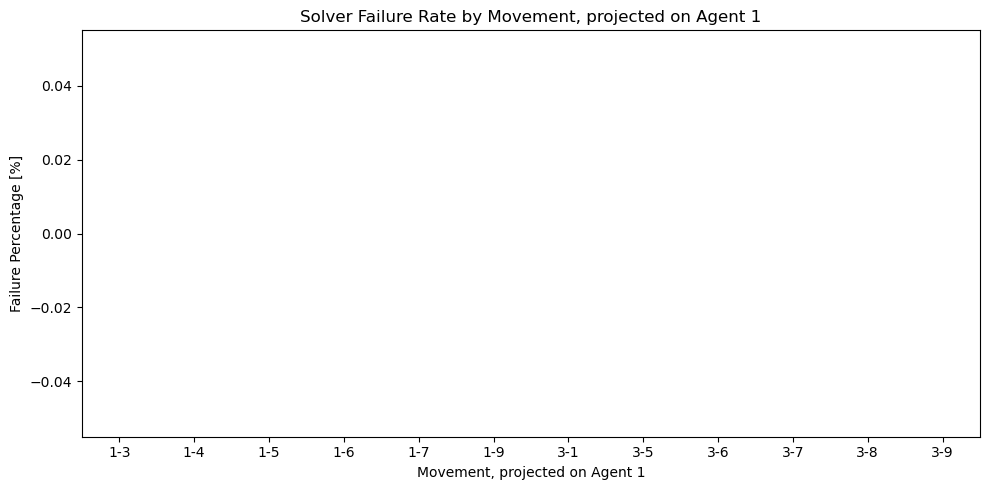

In [3]:
df["failure"] = ~df["converged"]

mirror = {
    1:5,
    2:6,
    3:7,
    4:8,
    5:1,
    6:2, 
    7:3,
    8:4,
    9:9,
}

def mirror_movement(start, goal):
    s = mirror[start]
    g = mirror[goal]
    return f"{s}-{g}"


df["projected_movement"] = np.where(
    df["agent"] == 1,
    df["movement"],
    df.apply(
        lambda r: mirror_movement(r["start"], r["goal"]),
        axis=1
    )
)

failure_rates = (
    df.groupby("projected_movement")["failure"]
      .mean()
      .mul(100)
      .reset_index(name="failure_percent")
      .sort_values("failure_percent", ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=failure_rates,
    x="projected_movement",
    y="failure_percent"
)

plt.ylabel("Failure Percentage [%]")
plt.xlabel("Movement, projected on Agent 1")
plt.title("Solver Failure Rate by Movement, projected on Agent 1")

plt.tight_layout()
plt.show()

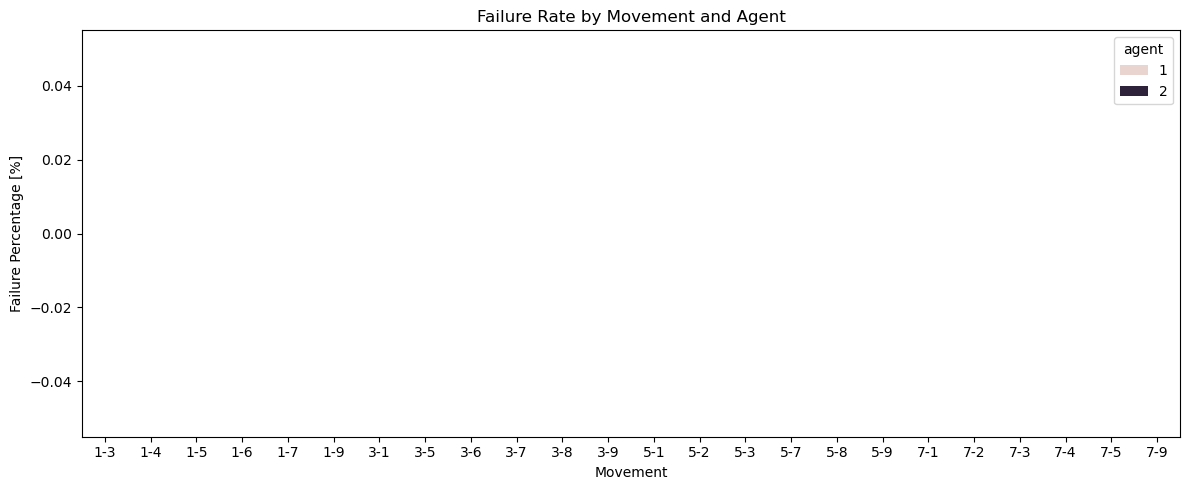

In [4]:
failure_rates = (
    df.groupby(["movement", "agent"])["failure"]
      .mean()
      .mul(100)
      .reset_index(name="failure_percent")
)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=failure_rates,
    x="movement",
    y="failure_percent",
    hue="agent"
)

plt.ylabel("Failure Percentage [%]")
plt.xlabel("Movement")
plt.title("Failure Rate by Movement and Agent")

plt.tight_layout()
plt.show()

In [5]:
print(df["agent"].value_counts())
print(df["agent"].value_counts())
print(df.groupby("agent")["movement"].unique())

agent
1    861
2    860
Name: count, dtype: int64
agent
1    861
2    860
Name: count, dtype: int64
agent
1    [3-6, 3-7, 3-5, 3-1, 1-3, 3-8, 1-6, 1-9, 3-9, ...
2    [7-1, 7-9, 5-8, 5-7, 7-5, 7-3, 7-2, 5-3, 5-2, ...
Name: movement, dtype: object


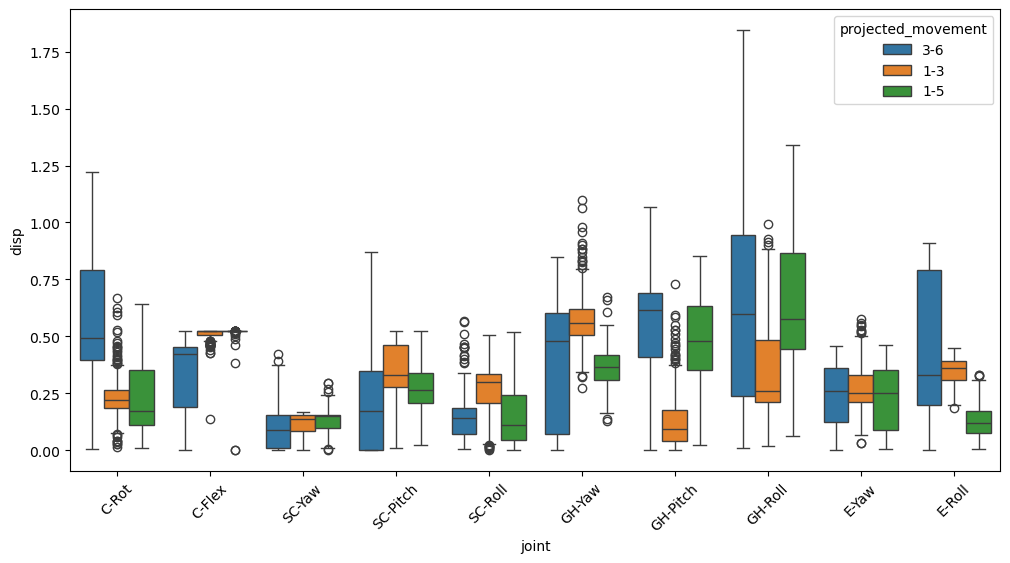

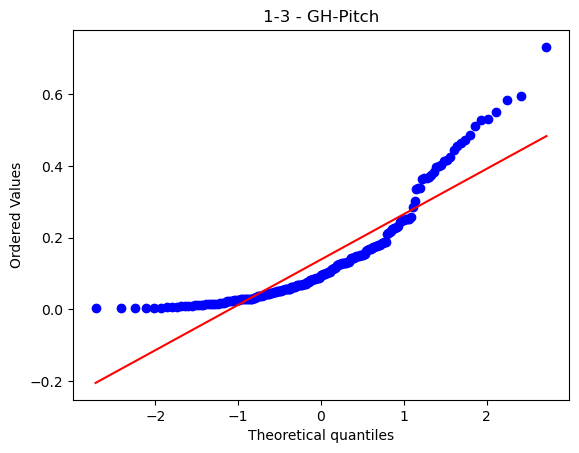

shapiro:  ShapiroResult(statistic=0.8163425922393799, pvalue=3.649145415230088e-15)


In [6]:
joint_order = [
    "columna_rot_joint",
    "columna_flex_joint",
    "sternoclavicular_yaw_joint",
    "sternoclavicular_pitch_joint",
    "sternoclavicular_roll_joint",
    "glenohumeral_yaw_joint",
    "glenohumeral_pitch_joint",
    "glenohumeral_roll_joint",
    "elbow_yaw_joint",
    "elbow_roll_joint",
]

movements = ["1-3", "1-5", "3-6" ] #, "3-1"]

rows = []

for _, row in df[df["converged"]].iterrows():

    if row["projected_movement"] not in movements:
        continue

    for j in joint_order:
        rows.append({
            "projected_movement": row["projected_movement"],
            "joint": j,
            "disp": abs(row[f"{j}_disp"])
        })

long_df = pd.DataFrame(rows)

joint_stats = long_df.groupby(["projected_movement", "joint"]).agg(
    mean=("disp", "mean"),
    std=("disp", "std")
).reset_index()

joint_labels = {
    "columna_rot_joint": "C-Rot",
    "columna_flex_joint": "C-Flex",
    "sternoclavicular_yaw_joint": "SC-Yaw",
    "sternoclavicular_pitch_joint": "SC-Pitch",
    "sternoclavicular_roll_joint": "SC-Roll",
    "glenohumeral_yaw_joint": "GH-Yaw",
    "glenohumeral_pitch_joint": "GH-Pitch",
    "glenohumeral_roll_joint": "GH-Roll",
    "elbow_yaw_joint": "E-Yaw",
    "elbow_roll_joint": "E-Roll",
}

joint_stats["joint"] = joint_stats["joint"].map(joint_labels)
long_df["joint"] = long_df["joint"].map(joint_labels)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=long_df,
    x="joint",
    y="disp",
    hue="projected_movement"
)

plt.xticks(rotation=45)
plt.show()

#Box plot?

movement = "1-3"
joint = "GH-Pitch"

x = long_df[
    (long_df.projected_movement == movement) &
    (long_df.joint == joint)
]["disp"]

from scipy.stats import probplot

probplot(x, dist="norm", plot=plt)
plt.title(f"{movement} - {joint}")
plt.show()

from scipy.stats import shapiro

print("shapiro: ", shapiro(x))

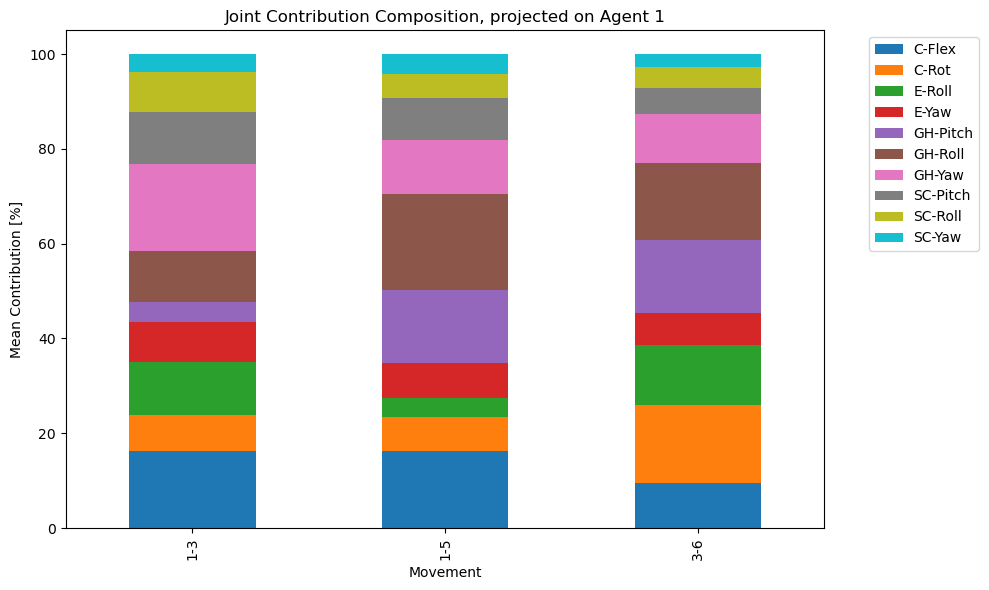

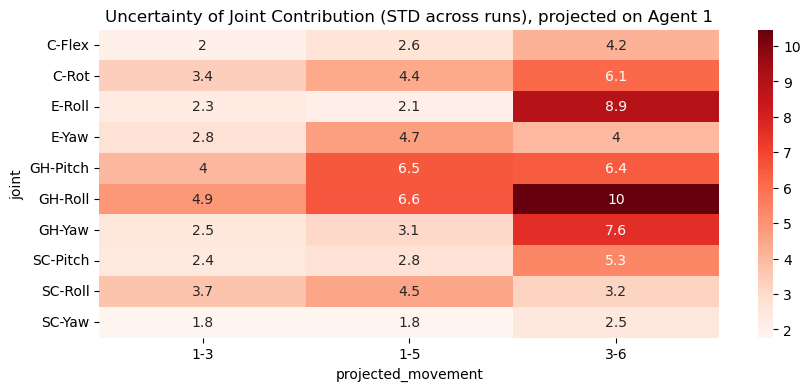

(1721, 36)
  projected_movement Angle
0                3-5  None
1                3-9  None
2                3-6  None
3                3-5  None
4                1-4  None
['3-5' '3-9' '3-6' '1-4' '3-7' '1-3' '3-1' '3-8' '1-6' '1-9' '1-7' '1-5']
object
1721


In [7]:
rows = []

for _, row in df[df["converged"]].iterrows():

    if row["projected_movement"] not in movements:
        continue

    disp = np.array([abs(row[f"{j}_disp"]) for j in joint_order])
    total = disp.sum()

    if total == 0:
        continue

    contrib = disp / total

    for j, c in zip(joint_order, contrib):

        rows.append({
            "projected_movement": row["projected_movement"],
            "joint": j,
            "contribution": c * 100
        })

long_df = pd.DataFrame(rows)

joint_stats = long_df.groupby(["projected_movement", "joint"]).agg(
    mean=("contribution", "mean"),
    std=("contribution", "std")
).reset_index()

joint_stats["joint"] = joint_stats["joint"].map(joint_labels)

pivot = joint_stats.pivot(
    index="projected_movement",
    columns="joint",
    values="mean"
)

ax = pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.ylabel("Mean Contribution [%]")
plt.xlabel("Movement")
plt.title("Joint Contribution Composition, projected on Agent 1")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

err = joint_stats.pivot(
    columns="projected_movement",
    index="joint",
    values="std"
)

plt.figure(figsize=(10,4))

sns.heatmap(
    err,
    annot=True,
    cmap="Reds"
)

plt.title("Uncertainty of Joint Contribution (STD across runs), projected on Agent 1")
plt.show()

subset = df[df["converged"]]

print(subset.shape)
print(subset[["projected_movement", "Angle"]].head())
print(subset["projected_movement"].unique())
print(subset["Angle"].dtype)
print(subset["Angle"].isna().sum())

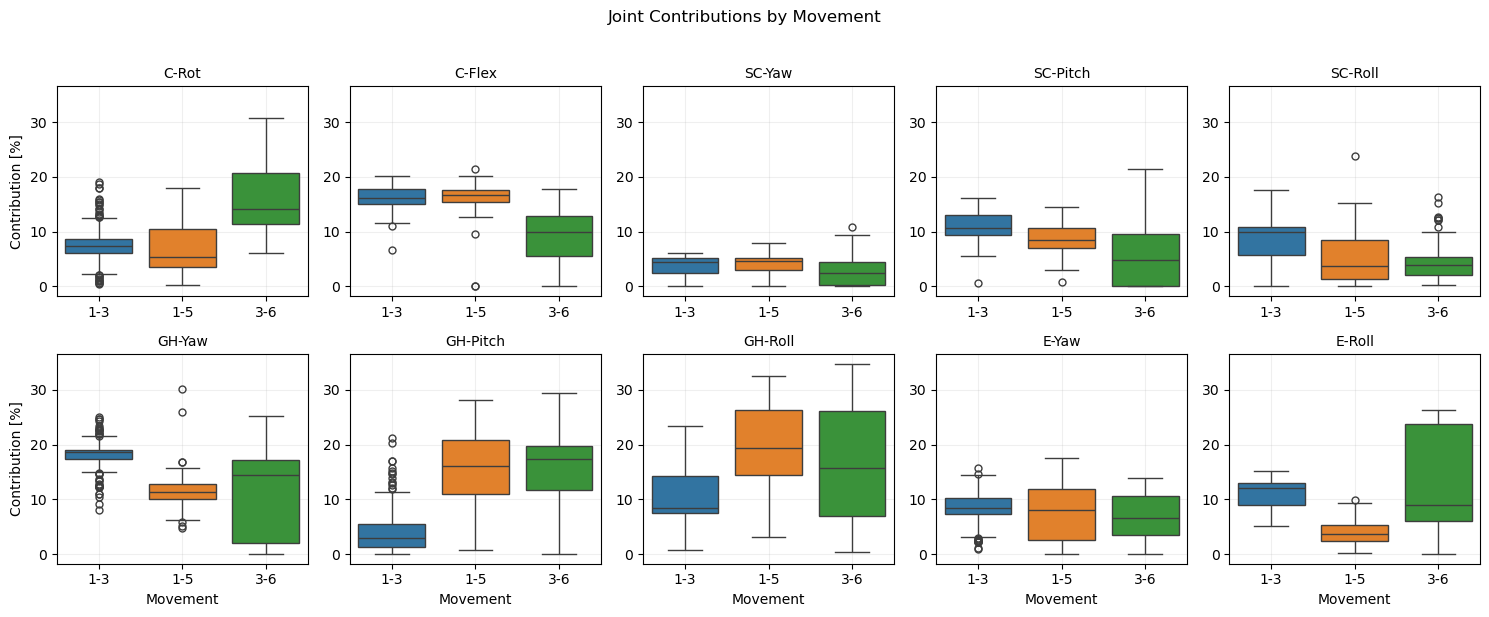

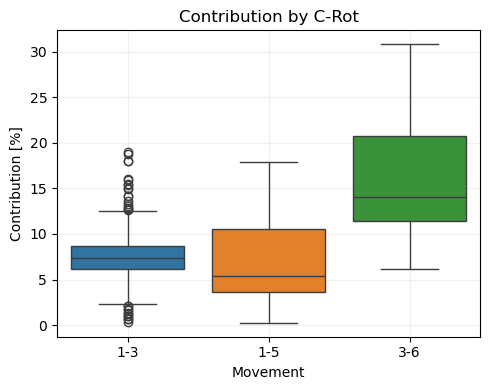

/tmp/ipykernel_33785/2826975888.py:112: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset.groupby("projected_movement")["contribution"]



=== Stats for C-Rot ===
projected_movement    median        q1        q3      iqr
               1-3  7.320111  6.111374  8.714422 2.603048
               1-5  5.405455  3.602997 10.584159 6.981162
               3-6 14.111653 11.467785 20.754486 9.286701


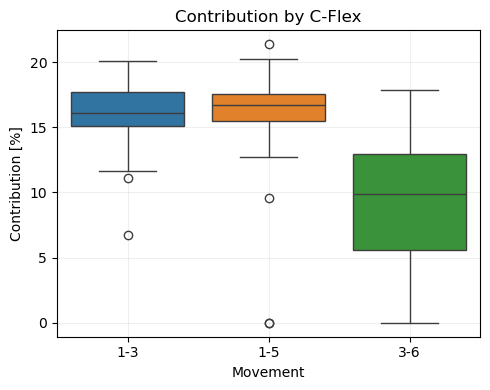


=== Stats for C-Flex ===
projected_movement    median        q1        q3      iqr
               1-3 16.119591 15.117054 17.735909 2.618855
               1-5 16.729751 15.494794 17.523559 2.028765
               3-6  9.912697  5.545072 12.941491 7.396419


/tmp/ipykernel_33785/2826975888.py:112: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset.groupby("projected_movement")["contribution"]


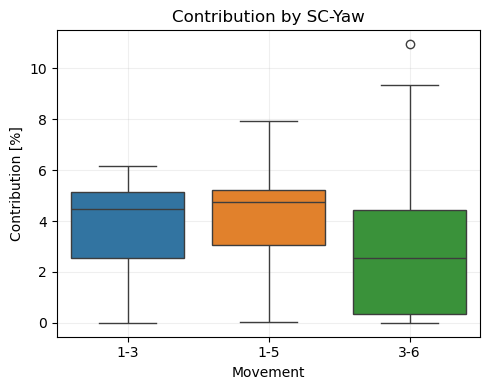

/tmp/ipykernel_33785/2826975888.py:112: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset.groupby("projected_movement")["contribution"]



=== Stats for SC-Yaw ===
projected_movement   median       q1       q3      iqr
               1-3 4.458455 2.547005 5.141997 2.594992
               1-5 4.738523 3.063613 5.238149 2.174536
               3-6 2.528794 0.350335 4.434719 4.084384


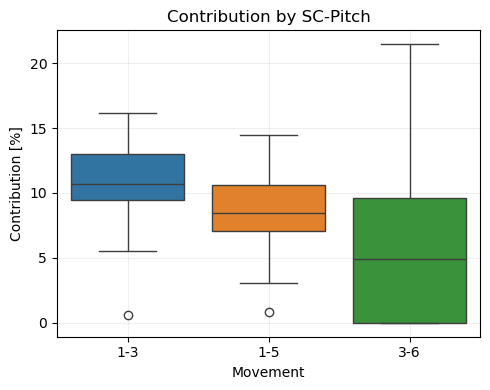


=== Stats for SC-Pitch ===
projected_movement    median       q1        q3      iqr
               1-3 10.687898 9.476382 13.041900 3.565517
               1-5  8.459297 7.066641 10.612724 3.546083
               3-6  4.888976 0.014385  9.605841 9.591455


/tmp/ipykernel_33785/2826975888.py:112: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset.groupby("projected_movement")["contribution"]


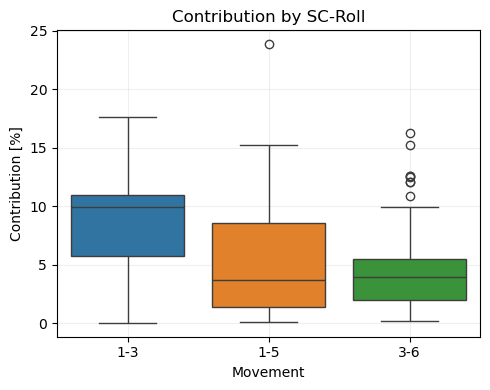

/tmp/ipykernel_33785/2826975888.py:112: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset.groupby("projected_movement")["contribution"]



=== Stats for SC-Roll ===
projected_movement   median       q1        q3      iqr
               1-3 9.979327 5.747012 10.942314 5.195302
               1-5 3.697029 1.353598  8.574340 7.220742
               3-6 3.983150 2.007102  5.455332 3.448229


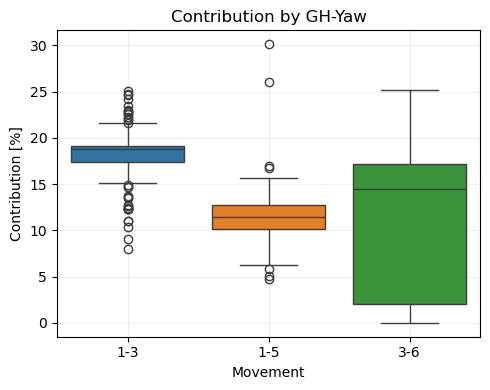

/tmp/ipykernel_33785/2826975888.py:112: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset.groupby("projected_movement")["contribution"]



=== Stats for GH-Yaw ===
projected_movement    median        q1        q3       iqr
               1-3 18.743671 17.431973 19.090149  1.658176
               1-5 11.387818 10.125032 12.744581  2.619549
               3-6 14.493101  1.986277 17.165596 15.179318


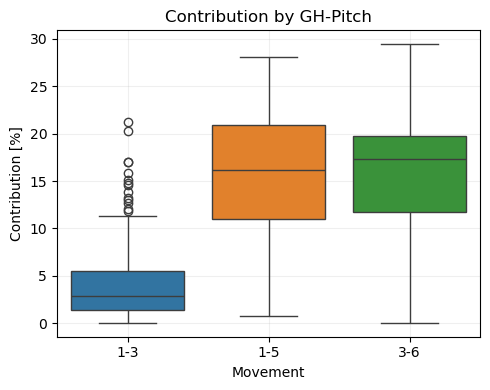

/tmp/ipykernel_33785/2826975888.py:112: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset.groupby("projected_movement")["contribution"]



=== Stats for GH-Pitch ===
projected_movement    median        q1        q3      iqr
               1-3  2.894600  1.389083  5.503232 4.114149
               1-5 16.151821 10.958418 20.870899 9.912481
               3-6 17.303951 11.749100 19.702287 7.953187


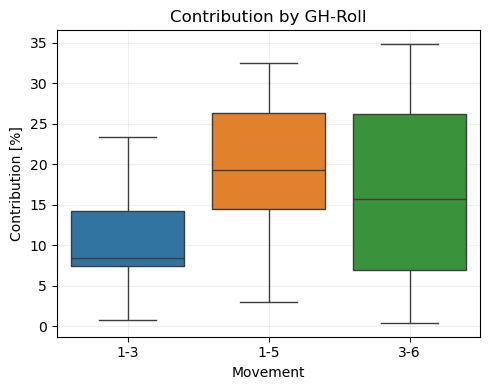

/tmp/ipykernel_33785/2826975888.py:112: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset.groupby("projected_movement")["contribution"]



=== Stats for GH-Roll ===
projected_movement    median        q1        q3       iqr
               1-3  8.441880  7.465479 14.210149  6.744670
               1-5 19.301411 14.534374 26.308918 11.774544
               3-6 15.688672  6.935755 26.232856 19.297101


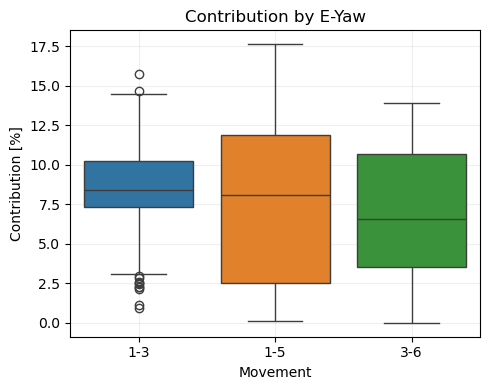


=== Stats for E-Yaw ===
projected_movement   median       q1        q3      iqr
               1-3 8.404828 7.346979 10.212661 2.865682
               1-5 8.090795 2.527448 11.887837 9.360389
               3-6 6.540506 3.499912 10.659861 7.159949


/tmp/ipykernel_33785/2826975888.py:112: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset.groupby("projected_movement")["contribution"]


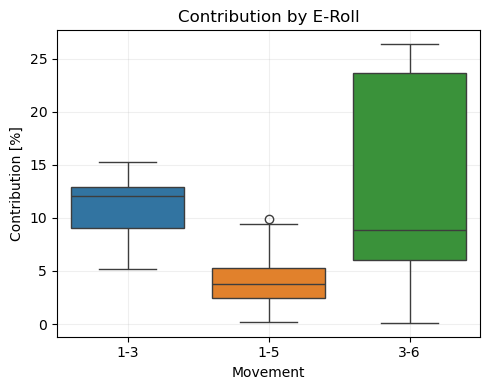


=== Stats for E-Roll ===
projected_movement    median       q1        q3       iqr
               1-3 12.108536 9.047841 12.955449  3.907608
               1-5  3.758859 2.423173  5.313788  2.890615
               3-6  8.904830 5.995291 23.686808 17.691517


/tmp/ipykernel_33785/2826975888.py:112: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset.groupby("projected_movement")["contribution"]


In [22]:
rows = []

for _, row in df[df["converged"]].iterrows():

    if row["projected_movement"] not in movements:
        continue

    disp = np.array([abs(row[f"{j}_disp"]) for j in joint_order])
    total = disp.sum()

    if total == 0:
        continue

    contrib = disp / total

    for j, c in zip(joint_order, contrib):

        rows.append({
            "projected_movement": row["projected_movement"],
            "joint": j,  # raw stable ID (NEVER TOUCH THIS AGAIN)
            "joint_label": joint_labels[j],  # display only
            "contribution": c * 100
        })

long_df = pd.DataFrame(rows)
long_df["joint_label"] = pd.Categorical(
    long_df["joint_label"],
    categories=[joint_labels[j] for j in joint_order],
    ordered=True
)

long_df["projected_movement"] = pd.Categorical(
    long_df["projected_movement"],
    categories=movements,
    ordered=True
)

palette = { "1-3": "#1f77b4", "1-5": "#ff7f0e", "3-6": "#2ca02c" }

def style_axes(ax):
    ax.set_xlim(-0.5, len(movements) - 0.5)
    ax.grid(True, alpha=0.2)

    for spine in ax.spines.values():
        spine.set_visible(True)

    ax.tick_params(axis="y", labelleft=True)

    palette = {
    "1-3": "#1f77b4",
    "1-5": "#ff7f0e",
    "3-6": "#2ca02c"
}

g = sns.catplot(
    data=long_df,
    x="projected_movement",
    y="contribution",
    col="joint_label",
    col_order=[joint_labels[j] for j in joint_order],  
    col_wrap=5,
    kind="box",
    hue="projected_movement",
    palette=palette,
    sharey=True,
    height=3,
    dodge=False,
    sharex=False
)

g.set_titles("{col_name}")
g.set_axis_labels("Movement", "Contribution [%]")

for ax in g.axes.flat:
    style_axes(ax)

g.fig.suptitle("Joint Contributions by Movement", y=1.02)

plt.tight_layout()
plt.show()

for joint_label in long_df["joint_label"].cat.categories:

    fig, ax = plt.subplots(figsize=(5, 4))

    subset = long_df[long_df["joint_label"] == joint_label]

    sns.boxplot(
        data=subset,
        x="projected_movement",
        y="contribution",
        hue="projected_movement",
        palette=palette,
        dodge=False,
        order=movements,  
        ax=ax
    )

    style_axes(ax)

    ax.set_title(f"Contribution by {joint_label}")
    ax.set_xlabel("Movement")
    ax.set_ylabel("Contribution [%]")

    if ax.get_legend() is not None:
        ax.legend_.remove()

    plt.tight_layout()
    plt.show()

    stats = (
        subset.groupby("projected_movement")["contribution"]
        .agg(
            median="median",
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75),
        )
        .reset_index()
    )

    stats["iqr"] = stats["q3"] - stats["q1"]

    print(f"\n=== Stats for {joint_label} ===")
    print(stats.to_string(index=False))

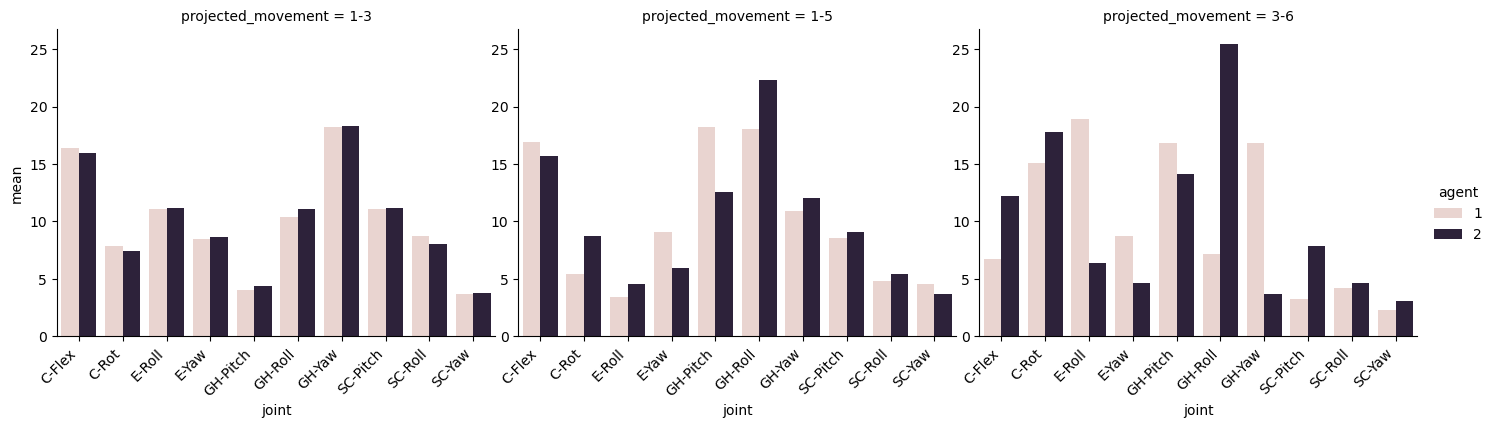

In [9]:
rows = []

for _, row in df[df["converged"]].iterrows():

    if row["projected_movement"] not in movements:
        continue

    disp = np.array([abs(row[f"{j}_disp"]) for j in joint_order])
    total = disp.sum()

    if total == 0:
        continue

    contrib = disp / total

    for j, c in zip(joint_order, contrib):
        rows.append({
            "projected_movement": row["projected_movement"],
            "agent": row["agent"],
            "joint": j,
            "contribution": c * 100
        })

long_df = pd.DataFrame(rows)

joint_stats = (
    long_df
    .groupby(["projected_movement", "agent", "joint"])
    .agg(
        mean=("contribution", "mean"),
        std=("contribution", "std")
    )
    .reset_index()
)

joint_stats["joint"] = joint_stats["joint"].map(joint_labels)


g = sns.catplot(
    data=joint_stats,
    kind="bar",
    x="joint",
    y="mean",
    hue="agent",
    col="projected_movement",
    col_wrap=3,
    height=4,
    aspect=1.2,
    errorbar=None,
    sharey=True
)

g.fig.subplots_adjust(hspace=0.3)

for ax in g.axes.flat:
    ax.tick_params(labelbottom=True)
    
for ax in g.axes.flat:
    ax.tick_params(axis="y", labelleft=True)

for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(),
             rotation=45,
             ha="right")
    


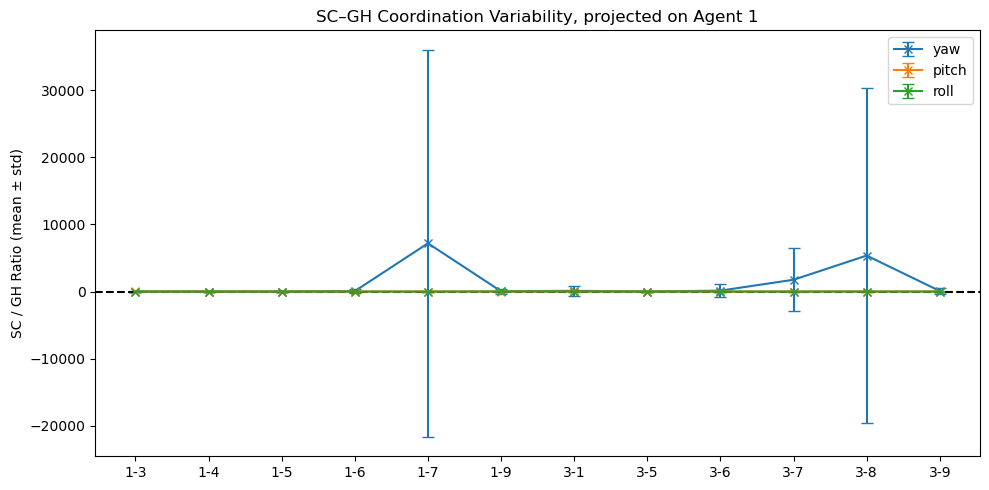

projected_movement  axis          SC/GH Ratio
               1-3   yaw        0.205 ± 0.098
               1-3 pitch       9.224 ± 16.674
               1-3  roll        1.139 ± 1.684
               1-4   yaw        0.199 ± 0.101
               1-4 pitch        3.387 ± 5.741
               1-4  roll        0.953 ± 0.472
               1-5   yaw        0.394 ± 0.230
               1-5 pitch        0.856 ± 1.102
               1-5  roll        0.370 ± 0.704
               1-6   yaw     65.374 ± 357.948
               1-6 pitch        0.153 ± 0.122
               1-6  roll        0.448 ± 0.377
               1-7   yaw 7184.113 ± 28840.144
               1-7 pitch        0.629 ± 1.485
               1-7  roll        1.041 ± 2.381
               1-9   yaw     37.442 ± 366.259
               1-9 pitch        0.624 ± 1.770
               1-9  roll      10.873 ± 71.101
               3-1   yaw    111.656 ± 708.930
               3-1 pitch       6.873 ± 24.403
               3-1  roll       4.4

In [10]:
sc_gh_pairs = [
    ("yaw",   "sternoclavicular_yaw_joint",   "glenohumeral_yaw_joint"),
    ("pitch", "sternoclavicular_pitch_joint", "glenohumeral_pitch_joint"),
    ("roll",  "sternoclavicular_roll_joint",  "glenohumeral_roll_joint"),
]

rows = []

for movement in sorted(df["projected_movement"].unique()):

    subset = df[
        (df["projected_movement"] == movement) &
        (df["converged"])
    ]

    for axis, sc, gh in sc_gh_pairs:

        sc_vals = subset[f"{sc}_disp"].abs()
        gh_vals = subset[f"{gh}_disp"].abs()

        ratio = sc_vals / gh_vals.replace(0, np.nan)
        #ratio = np.log((sc_vals + 1e-8) / (gh_vals + 1e-8))

        rows.append({
            "projected_movement": movement,
            "axis": axis,
            "mean": ratio.mean(),
            "std": ratio.std() 
        })

joint_stats = pd.DataFrame(rows)

plt.figure(figsize=(10,5))

for axis in joint_stats["axis"].unique():

    sub = joint_stats[joint_stats["axis"] == axis]

    plt.errorbar(
        sub["projected_movement"],
        sub["mean"],
        yerr= sub["std"],
        label=axis,
        capsize=4,
        marker="x"
    )

plt.axhline(0.5, linestyle="--", color="black")

plt.ylabel("SC / GH Ratio (mean ± std)")
plt.title("SC–GH Coordination Variability, projected on Agent 1")

#plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()


table = joint_stats.copy()

table["SC/GH Ratio"] = (
    table["mean"].map(lambda x: f"{x:.3f}")
    + " ± "
    + table["std"].map(lambda x: f"{x:.3f}")
)

table = table[["projected_movement", "axis", "SC/GH Ratio"]]

print(table.to_string(index=False))

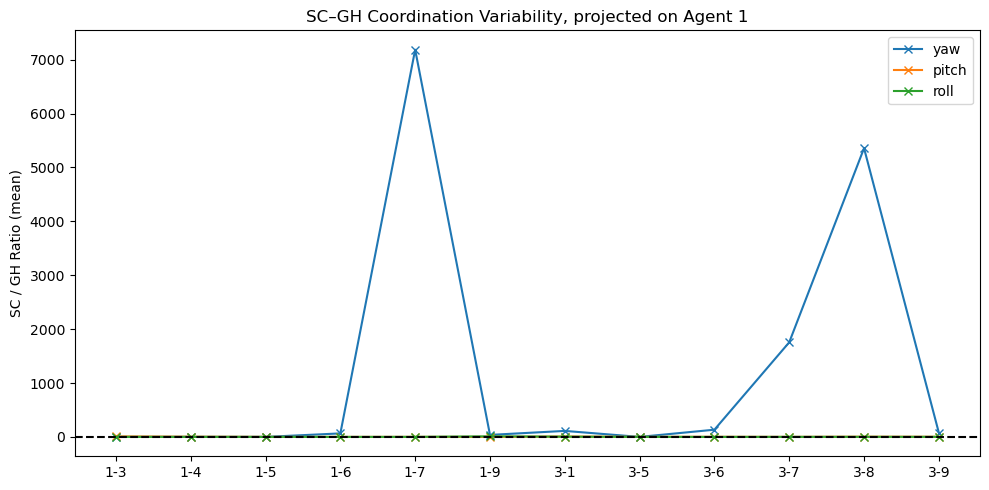

In [11]:
# same shit as before but without error bars:
plt.figure(figsize=(10,5))

# enforce consistent order
movement_order = sorted(joint_stats["projected_movement"].unique())

for axis in joint_stats["axis"].unique():

    sub = joint_stats[joint_stats["axis"] == axis]

    # force alignment with movement order
    sub = sub.set_index("projected_movement").reindex(movement_order).reset_index()

    plt.plot(
        sub["projected_movement"],
        sub["mean"],
        label=axis,
        marker="x"
    )

plt.axhline(0.5, linestyle="--", color="black")

plt.ylabel("SC / GH Ratio (mean)")
plt.title("SC–GH Coordination Variability, projected on Agent 1")

plt.legend()
plt.tight_layout()
plt.show()
#box plot, outlier raus 

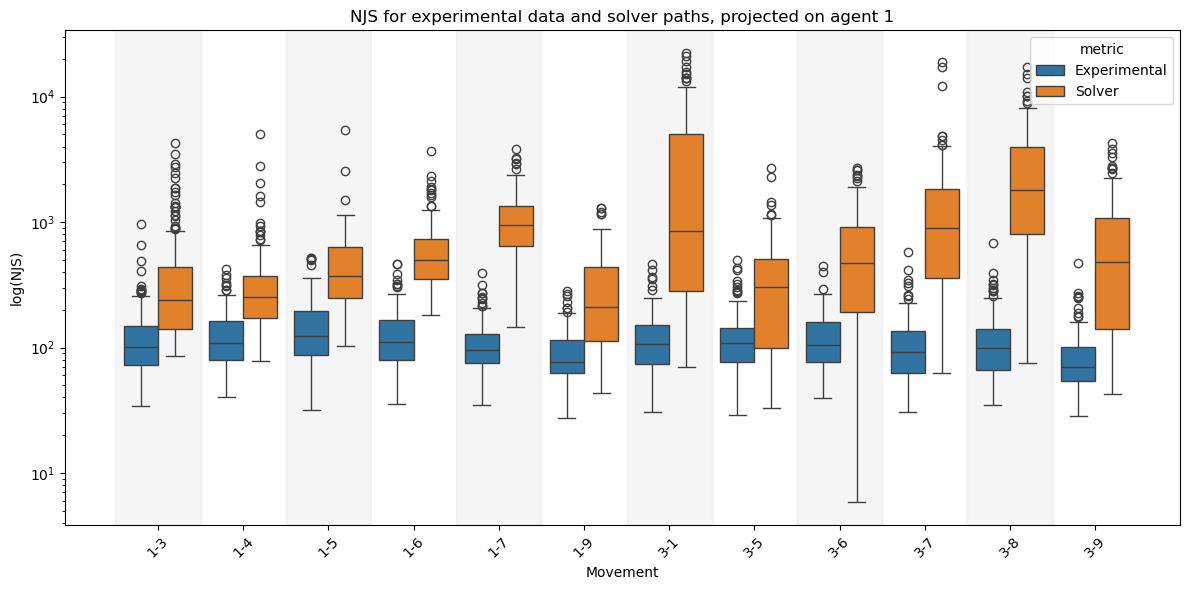

                   Solution_EE_NJS                                         \
                             count         mean       median          std   
projected_movement                                                          
1-3                            214   431.623044   239.611478   568.699739   
1-4                            130   388.968385   251.931883   545.903237   
1-5                            133   498.495364   371.161507   534.178214   
1-6                            131   639.711097   494.541391   495.305170   
1-7                            135  1091.327720   952.995011   661.576592   
1-9                            134   311.128869   210.610344   267.561334   
3-1                            181  3412.341301   850.099064  4609.117696   
3-5                            136   393.428826   302.099189   405.169580   
3-6                            131   672.982051   471.328284   630.454058   
3-7                            134  1548.860820   903.847860  2511.439754   

/usr/lib/python3/dist-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/lib/python3/dist-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/lib/python3/dist-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/lib/python3/dist-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/lib/python3/dist-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/lib/python3/dist-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/lib/python3/dist-packages/numpy/lib/nanfunctions.py:1215: R

In [12]:
rows = []

for movement, group in df.groupby("projected_movement"):

    # EE_NJS (all runs)
    for v in group["EE_NJS"].dropna():
        rows.append({
            "projected_movement": movement,
            "metric": "EE_NJS",
            "value": v
        })

    # Solver (only converged)
    converged = group[group["converged"]]

    for v in converged["Solution_EE_NJS"].dropna():
        rows.append({
            "projected_movement": movement,
            "metric": "Solution_EE_NJS",
            "value": v
        })

    for v in converged["Solution_EE_NJS_cropped"].dropna():
        rows.append({
            "projected_movement": movement,
            "metric": "Solution_EE_NJS_cropped",
            "value": v
        })

metric_labels = {
    "EE_NJS": "Experimental",
    "Solution_EE_NJS": "Solver",
    "Solution_EE_NJS_cropped" : "Solver, from Waypoint 1"
}


long_df = pd.DataFrame(rows)
long_df["metric"] = long_df["metric"].map(metric_labels)

plt.figure(figsize=(12, 6))

ax = sns.boxplot(
    data=long_df,
    x="projected_movement",
    y="value",
    hue="metric",
    showfliers=True
)

ax.set_yscale("log")

x_labels = sorted(long_df["projected_movement"].unique())
for i, m in enumerate(x_labels):
    if i % 2 == 0:
        ax.axvspan(i - 0.5, i + 0.5, color="gray", alpha=0.08)

plt.ylabel("log(NJS)")
plt.xlabel("Movement")
plt.xticks(rotation=45)
plt.title("NJS for experimental data and solver paths, projected on agent 1")

plt.tight_layout()
plt.show()

summary = (
    df[df["converged"]]
    .groupby("projected_movement")
    [["Solution_EE_NJS", "Solution_EE_NJS_cropped"]]
    .agg(["count", "mean", "median", "std"])
)

print(summary)

df_conv = df[df["converged"]].dropna(subset=[
    "Solution_EE_NJS",
    "Solution_EE_NJS_cropped"
])

improvement = (df_conv["Solution_EE_NJS"] - df_conv["Solution_EE_NJS_cropped"]) / df_conv["Solution_EE_NJS"]

global_improvement_mean = 100 * improvement.mean()
gim_std = 100* improvement.std()
global_improvement_median = 100* improvement.median()
print("global improvement: mean:",global_improvement_mean, " pm ", gim_std ," median: ", global_improvement_median)

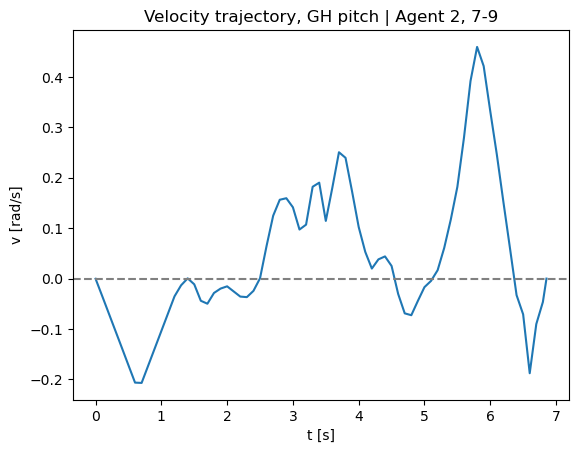

[(0.0, -0.0003433305813927904), (0.1, -0.03433305813927915), (0.2, -0.06866611627855772), (0.30000000000000004, -0.10299917441783958), (0.4, -0.13733223255711494), (0.5, -0.1719390140807879), (0.6000000000000001, -0.20630074265713455), (0.7000000000000001, -0.20690547676641372), (0.8, -0.17258670900892503), (0.9, -0.1382437357121011), (1.0, -0.10389272620156764), (1.1, -0.0695417166910187), (1.2, -0.03519070718047716), (1.3, -0.013296319015519947), (1.4, 0.00047660564897300875), (1.5, -0.011321137675306863), (1.6, -0.04398026742609379), (1.7000000000000002, -0.049802363949820815), (1.8, -0.02852429237972677), (1.9, -0.019819610864675305), (2.0, -0.015333234092641607), (2.1, -0.02551080418446712), (2.2, -0.03568837427629256), (2.3, -0.03674038894396566), (2.4, -0.024370157352411416), (2.5, 0.0006030074301994077), (2.6, 0.06504576897319483), (2.7, 0.12473961011436542), (2.8, 0.15637098322961168), (2.9, 0.1594054370230887), (3.0, 0.14140605883676605), (3.1, 0.09731334835874372), (3.2, 0.1

In [13]:
row = df.iloc[1]
mv = row["movement"]
ag = row["agent"]

t = row["trajectory_time"]
v = row["glenohumeral_pitch_joint_vel"]

t = np.array(t)
v = np.array(v)

mask = ~np.isnan(t)
t = t[mask]
v = v[mask]

plt.plot(t, v)

plt.title(f"Velocity trajectory, GH pitch | Agent {ag}, {mv}")
plt.axhline(0.0, linestyle="--", color="grey")

plt.xlabel("t [s]")
plt.ylabel("v [rad/s]")
plt.show()

print(list(zip(t, v)))

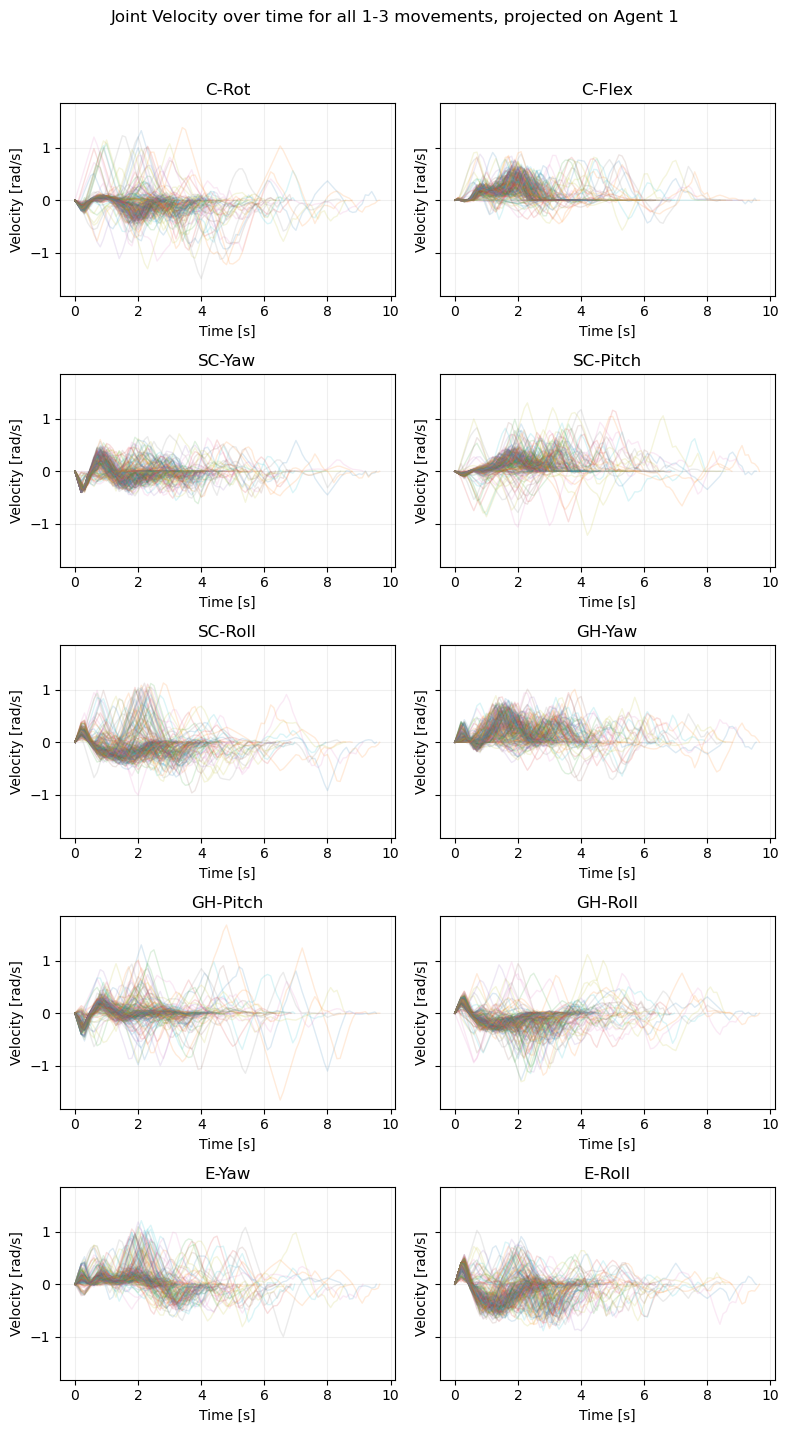

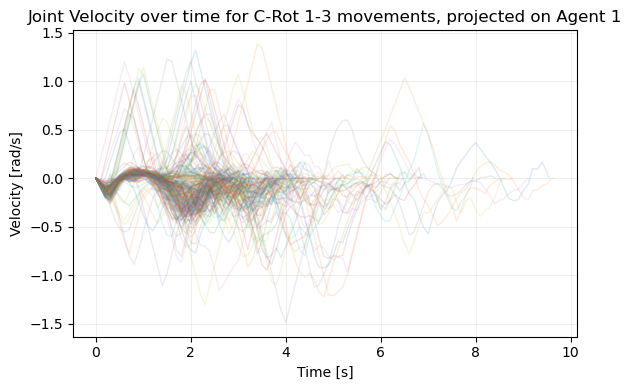

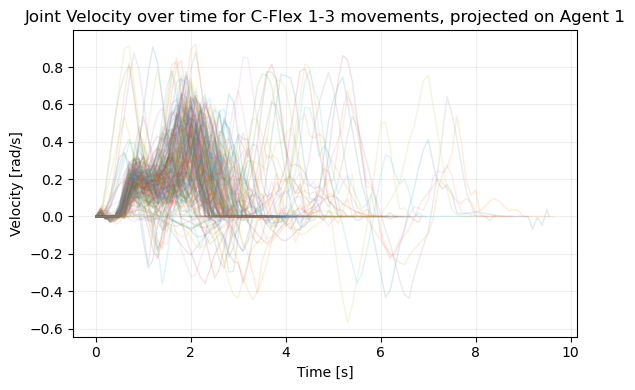

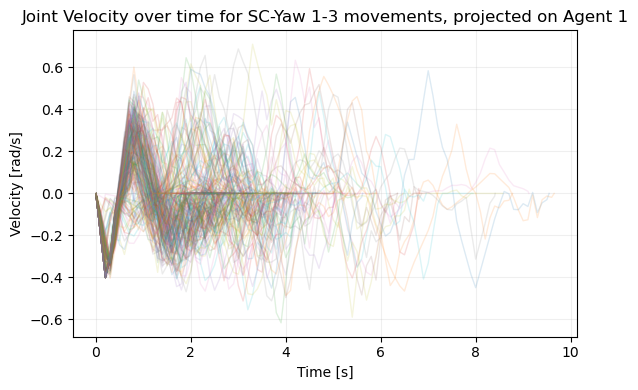

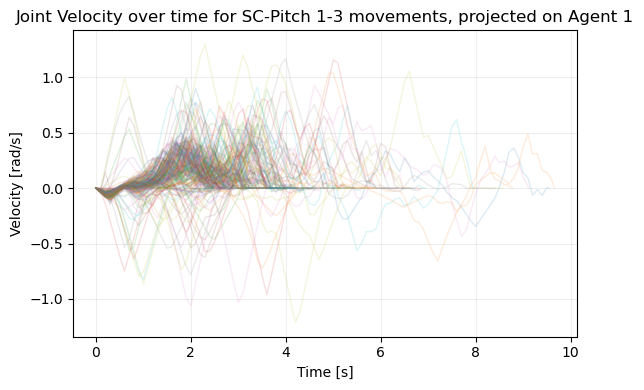

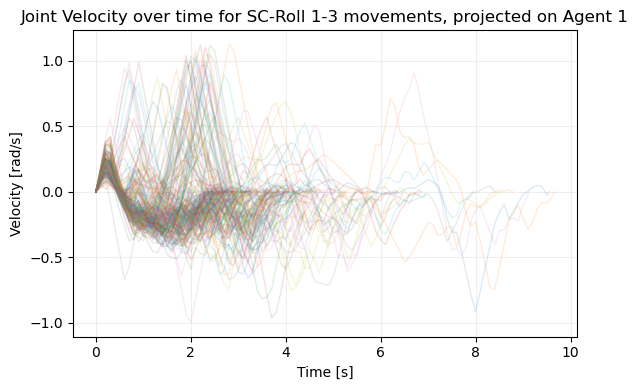

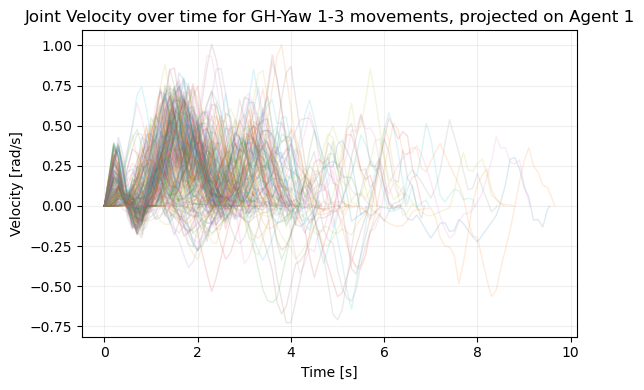

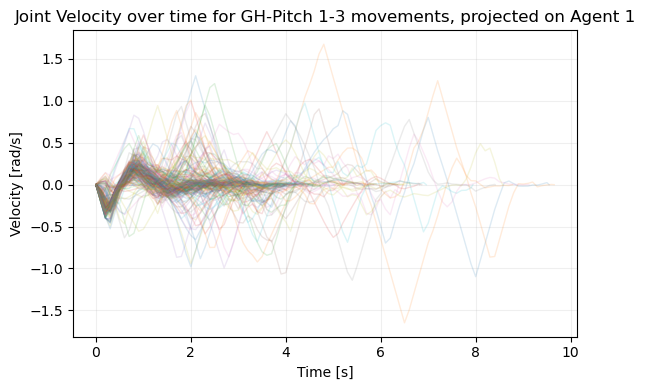

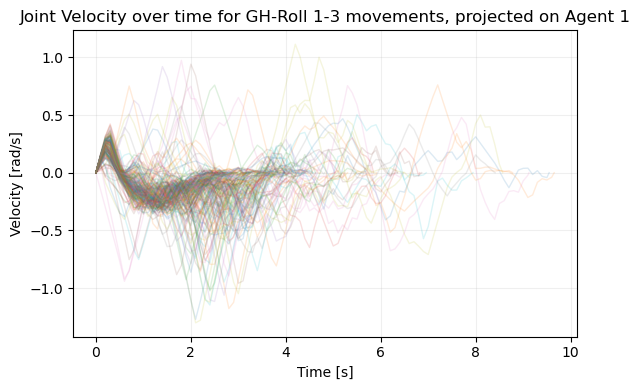

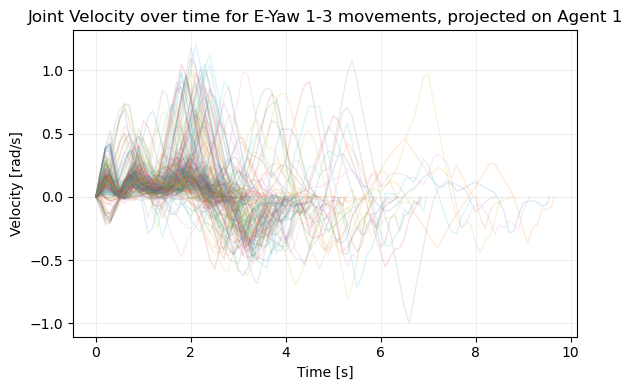

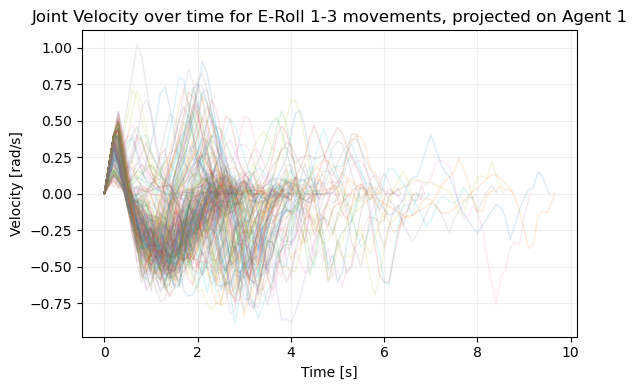

In [14]:
def plot_joint_velocity(ax, joint, movements_to_plot):

    vel_key = f"{joint}_vel"

    for movement in movements_to_plot:

        subset = df[
            (df["converged"]) &
            (df["projected_movement"] == movement)
        ]

        if len(subset) == 0:
            continue

        for _, row in subset.iterrows():

            t = row.get("trajectory_time")
            v = row.get(vel_key)

            if t is None or v is None:
                continue

            t = np.asarray(t)
            v = np.asarray(v)

            if len(t) != len(v):
                continue

            mask = ~np.isnan(t)
            t = t[mask]
            v = v[mask]

            if len(t) < 2:
                continue

            ax.plot(
                t,
                v,
                alpha=0.15,
                linewidth=1
            )

    ax.set_title(joint_labels.get(joint, joint))
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Velocity [rad/s]")
    ax.grid(True, alpha=0.2)

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(8, 14),
    sharex=False,
    sharey=True
)

axes = axes.flatten()

for ax, joint in zip(axes, joint_order):
    plot_joint_velocity(ax, joint, ["1-3"])

# hide unused axes if fewer than 10 joints
for ax in axes[len(joint_order):]:
    ax.set_visible(False)

fig.suptitle(
    "Joint Velocity over time for all 1-3 movements, projected on Agent 1",
    y=1.02
)

plt.tight_layout()
plt.show()


for joint in joint_order:

    fig, ax = plt.subplots(figsize=(6, 4))

    plot_joint_velocity(ax, joint, ["1-3"])

    title = "Joint Velocity over time for " + joint_labels.get(joint, joint) + " 1-3 movements, projected on Agent 1"
    plt.title(title)

    plt.tight_layout()


    plt.show()

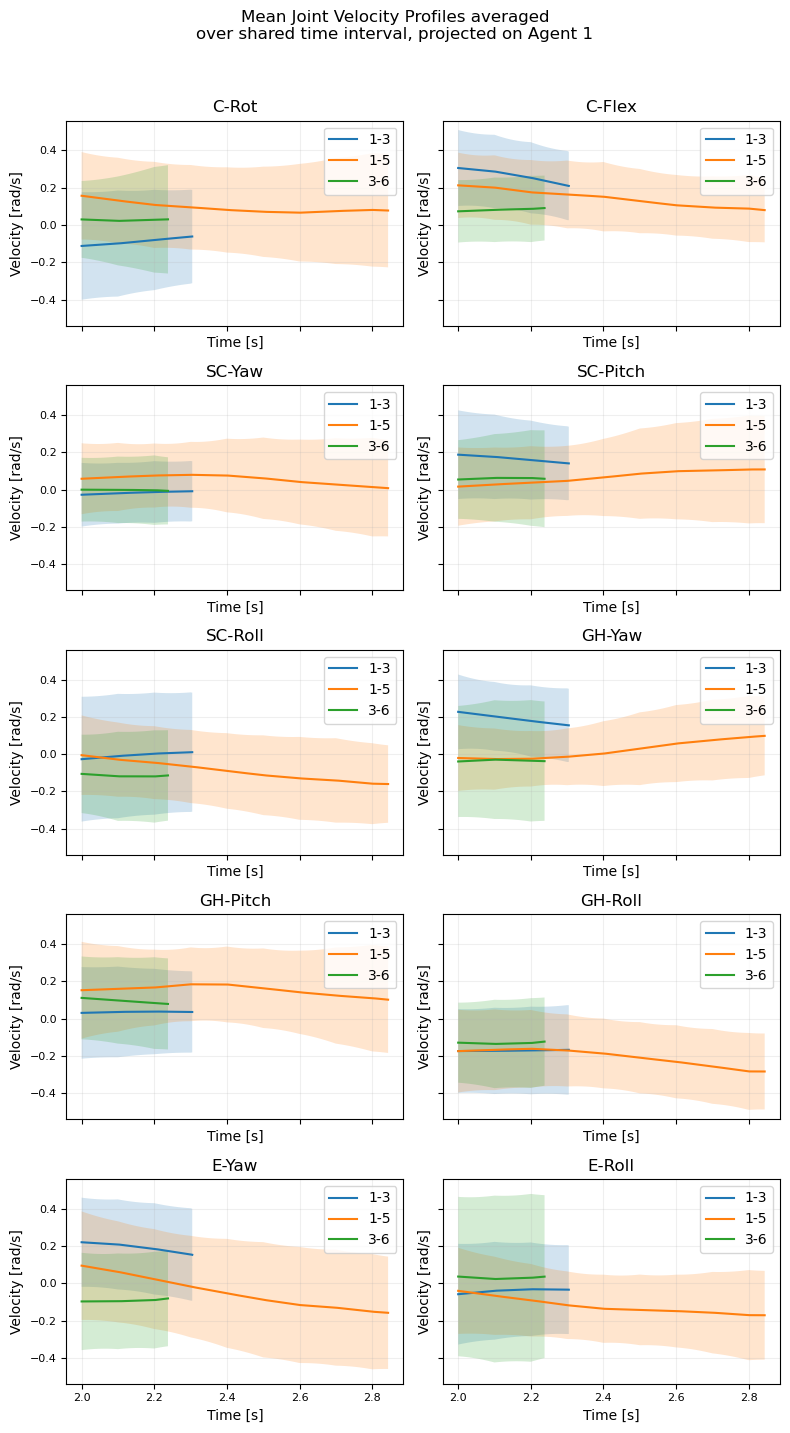

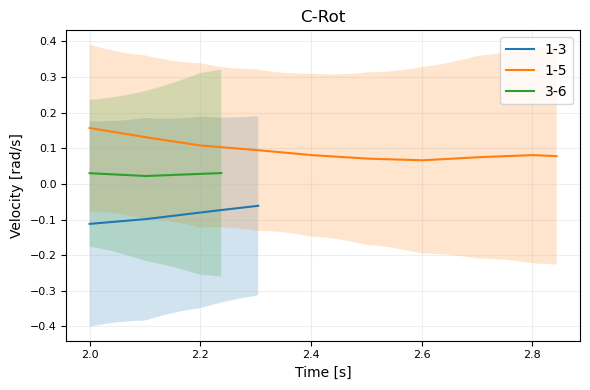

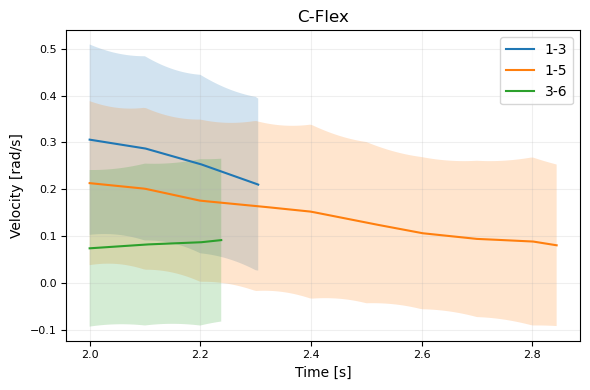

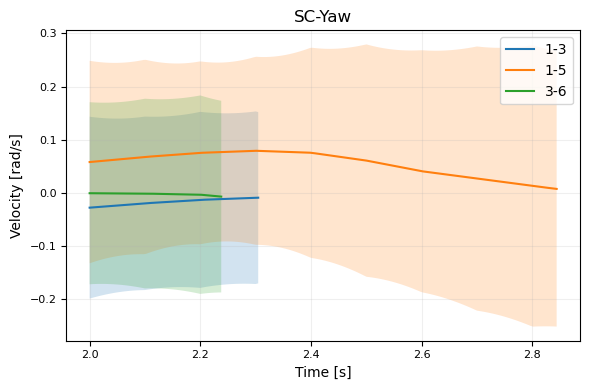

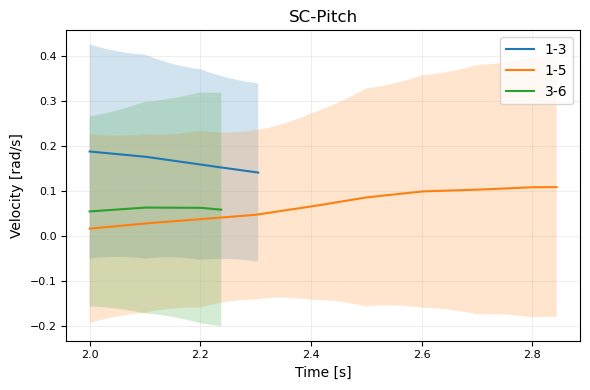

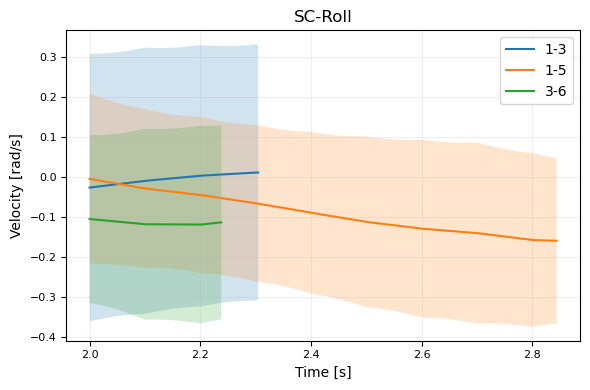

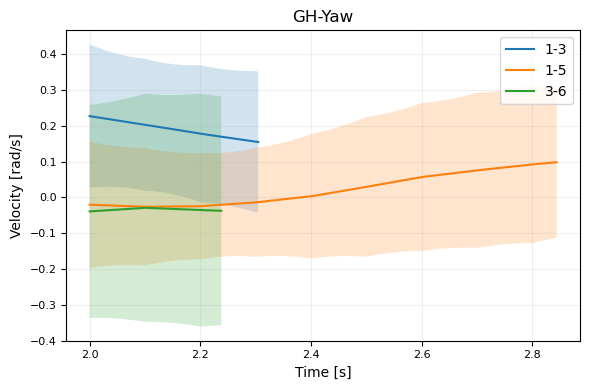

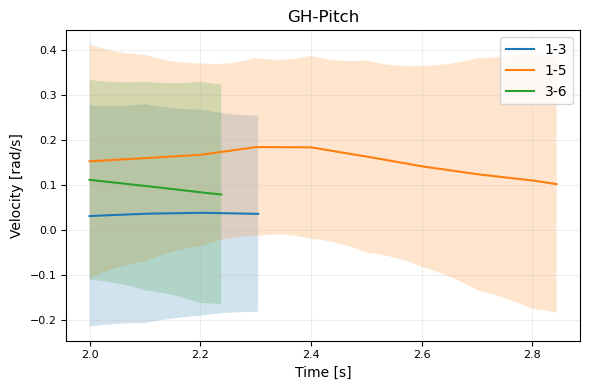

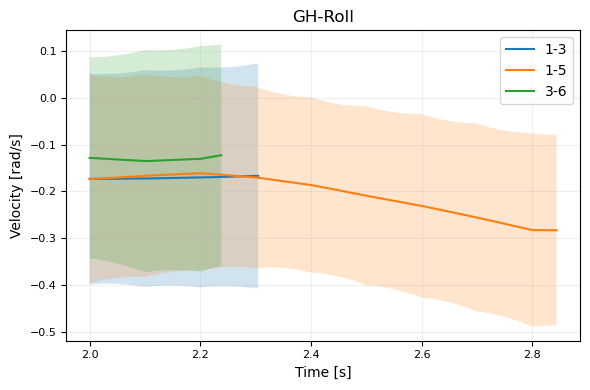

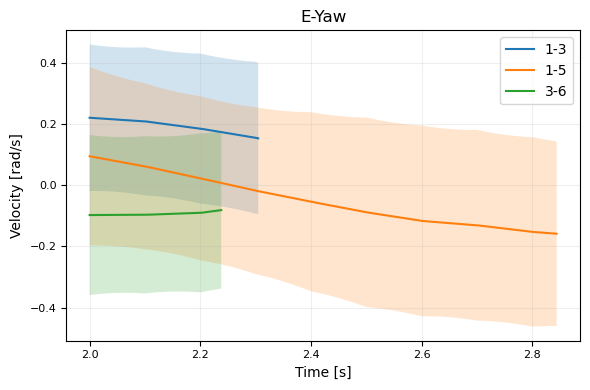

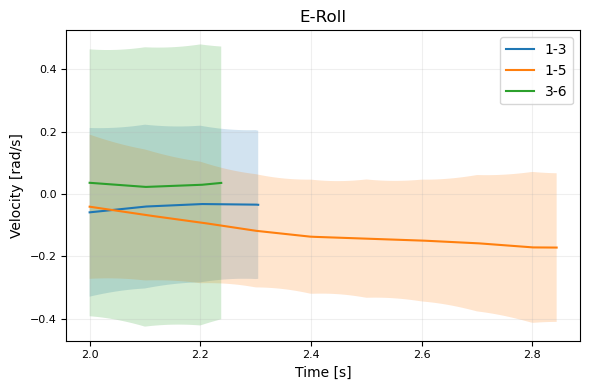

In [15]:
from scipy.interpolate import interp1d

NOISE_CUTOFF = 200 * 0.01

def plot_mean_velocity_profile(ax, joint, movements_to_plot):

    vel_key = f"{joint}_vel"

    for movement in movements_to_plot:

        subset = df[
            (df["converged"]) &
            (df["projected_movement"] == movement)
        ]

        if len(subset) == 0:
            continue

        traj_data = []

        for _, row in subset.iterrows():

            t = row.get("trajectory_time")
            v = row.get(vel_key)

            if t is None or v is None:
                continue

            t = np.asarray(t)
            v = np.asarray(v)

            mask = ~np.isnan(t)
            t = t[mask]
            v = v[mask]

            if len(t) < 2:
                continue

            valid = t >= (t[0] + NOISE_CUTOFF)

            t = t[valid]
            v = v[valid]

            if len(t) < 2:
                continue

            traj_data.append((t, v))

        if len(traj_data) == 0:
            continue

        # common overlapping interval
        t_start = max(t[0] for t, _ in traj_data)
        t_end   = min(t[-1] for t, _ in traj_data)

        if t_end <= t_start:
            continue

        common_t = np.linspace(t_start, t_end, 200)

        aligned = []

        for t, v in traj_data:

            f = interp1d(
                t,
                v,
                kind="linear",
                bounds_error=False,
                fill_value="extrapolate"
            )

            aligned.append(f(common_t))

        aligned = np.asarray(aligned)

        mean_traj = aligned.mean(axis=0)
        std_traj  = aligned.std(axis=0)

        ax.plot(common_t, mean_traj, label=movement)

        ax.fill_between(
            common_t,
            mean_traj - std_traj,
            mean_traj + std_traj,
            alpha=0.2
        )

    ax.set_title(joint_labels.get(joint, joint))
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Velocity [rad/s]")
    ax.grid(True, alpha=0.2)
    ax.tick_params(axis="both", labelsize=8)

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(8, 14),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, joint in zip(axes, joint_order):

    plot_mean_velocity_profile(
        ax,
        joint,
        movements
    )

    ax.legend()

# hide unused axes
for ax in axes[len(joint_order):]:
    ax.set_visible(False)

fig.suptitle(
    "Mean Joint Velocity Profiles averaged\n"
    "over shared time interval, projected on Agent 1",
    y=1.02
)

plt.tight_layout()
plt.show()


for joint in joint_order:

    fig, ax = plt.subplots(figsize=(6, 4))

    plot_mean_velocity_profile(
        ax,
        joint,
        movements
    )

    ax.legend()

    plt.tight_layout()

    plt.show()

(131, 36)
    projected_movement Angle
1                  3-9  None
20                 3-9  None
46                 3-9  None
110                3-9  None
111                3-9  None
['3-9']
object
131
(1721, 36)
  projected_movement Angle
0                3-5  None
1                3-9  None
2                3-6  None
3                3-5  None
4                1-4  None
['3-5' '3-9' '3-6' '1-4' '3-7' '1-3' '3-1' '3-8' '1-6' '1-9' '1-7' '1-5']
object
1721


ValueError: List of boxplot statistics and `positions` values must have same the length

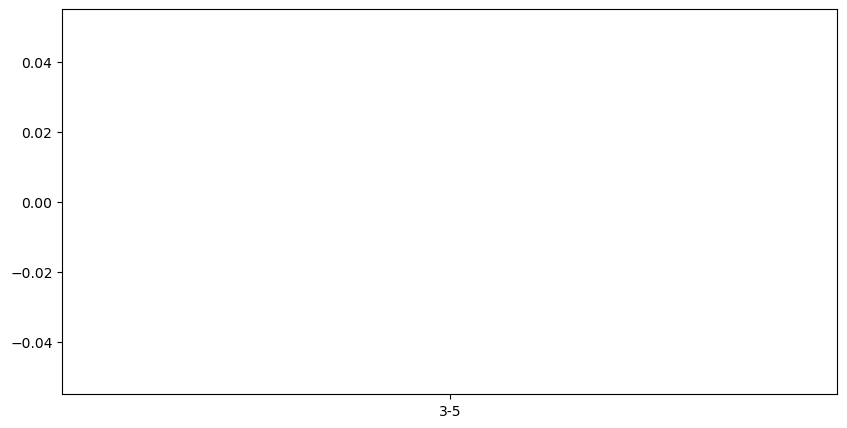

In [16]:
print(subset.shape)
print(subset[["projected_movement", "Angle"]].head())
print(subset["projected_movement"].unique())
print(subset["Angle"].dtype)
print(subset["Angle"].isna().sum())


subset = df[df["converged"]]

print(subset.shape)
print(subset[["projected_movement", "Angle"]].head())
print(subset["projected_movement"].unique())
print(subset["Angle"].dtype)
print(subset["Angle"].isna().sum())

plt.figure(figsize=(10, 5))

ax = sns.boxplot(
    data=subset,
    x="projected_movement",
    y="Angle",
    showfliers=True
)

for i in range(len(sorted(subset["projected_movement"].unique()))):
    if i % 2 == 0:
        ax.axvspan(i - 0.5, i + 0.5,
                   color="gray", alpha=0.08, zorder=0)

ax.axhline(
    y=90,
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label="90°"
)

ax.axhline(
    y=115,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="115°"
)


ax.legend()
ax.set_ylabel("ESA [°]")
ax.set_xlabel("Movement")


plt.title("ESA at the end of movement, projected on Agent 1")
plt.tight_layout()
plt.show()
print(min(subset["Angle"]))

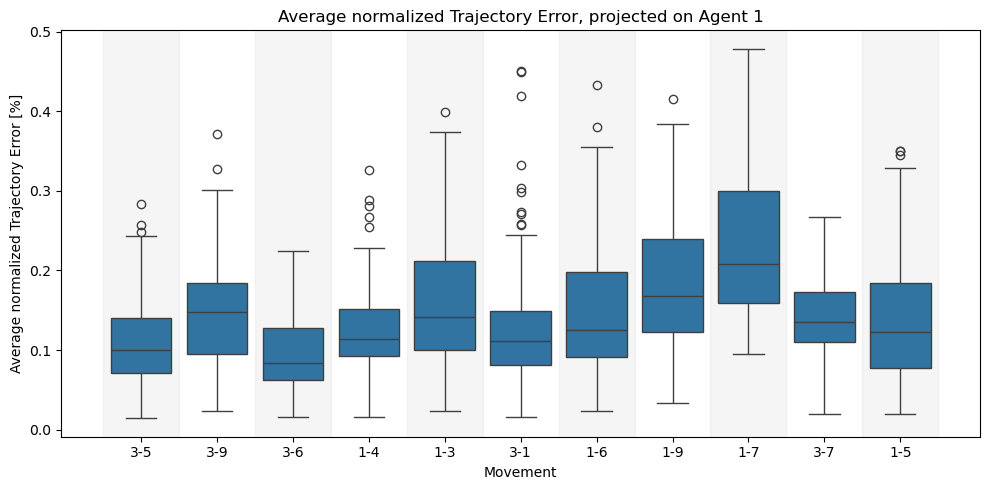

In [ ]:
subset = df[df["converged"]].copy()

subset["av_dist_to_target_pct"] = subset["av_dist_to_target"] * 100
plt.figure(figsize=(10, 5))

ax = sns.boxplot(
    data=subset,
    x="projected_movement",
    y="av_dist_to_target_pct",
    showfliers=True
)

for i in range(len(sorted(subset["projected_movement"].unique()))):
    if i % 2 == 0:
        ax.axvspan(i - 0.5, i + 0.5,
                   color="gray", alpha=0.08, zorder=0)


ax.set_ylabel("Average normalized Trajectory Error [%]")
ax.set_xlabel("Movement")


plt.title("Average normalized Trajectory Error, projected on Agent 1")
plt.tight_layout()
plt.show()